# Red Team: Attack-Path Emulation Planning

**Track:** Red team / adversary emulation

Prioritize authorized emulation scenarios by combining mission impact, control gaps, expected evidence, and analyst workload.

> **Safety boundary:** This lab is an offline analytical simulation. It contains no payloads, credential collection, exploitation steps, delivery infrastructure, or instructions for targeting real systems.

## Goal

Build a risk-based emulation backlog, compare an explainable score with two ML models, and identify scenarios that provide high learning value without overwhelming defenders.


## Setup

The notebook uses deterministic synthetic data, an inspectable baseline, held-out evaluation, and figures designed for GitHub preview. Metrics demonstrate the workflow—not production effectiveness.


In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

BLUE = "#2F6B9A"
GOLD = "#D39A2C"
ORANGE = "#D66B3D"
OLIVE = "#71834A"
PINK = "#B05A7A"
SLATE = "#566573"
PALETTE = [BLUE, GOLD, ORANGE, OLIVE, PINK, SLATE]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "font.size": 9,
})

def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(values, -30, 30)))

def model_metrics(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def top_k_metrics(labels, probabilities, review_capacity):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    selected = np.argsort(probabilities)[-review_capacity:]
    predictions = np.zeros(len(probabilities), dtype=int)
    predictions[selected] = 1
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def build_pipeline(numeric_features, categorical_features, estimator):
    transformer = ColumnTransformer([
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])
    return Pipeline([("features", transformer), ("model", estimator)])

def feature_importance_table(pipeline):
    names = pipeline.named_steps["features"].get_feature_names_out()
    model = pipeline.named_steps["model"]
    values = (
        np.abs(model.coef_[0])
        if hasattr(model, "coef_")
        else model.feature_importances_
    )
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


## Steps

### 1. Generate a safe emulation-planning dataset


In [2]:
tactics = np.array([
    "Initial access", "Execution", "Persistence", "Privilege escalation",
    "Discovery", "Lateral movement", "Collection", "Exfiltration",
])
techniques = {
    "Initial access": "Simulated access-policy test",
    "Execution": "Benign execution-control test",
    "Persistence": "Safe persistence-control check",
    "Privilege escalation": "Privilege-boundary simulation",
    "Discovery": "Synthetic discovery activity",
    "Lateral movement": "Segmentation-control simulation",
    "Collection": "Canary-data access simulation",
    "Exfiltration": "Egress-control simulation",
}
tactic_effect = dict(zip(tactics, [0.30, 0.15, 0.25, 0.55, -0.10, 0.50, 0.35, 0.65]))

scenario_count = 1800
tactic = rng.choice(tactics, scenario_count, p=[0.13, 0.14, 0.10, 0.11, 0.14, 0.13, 0.12, 0.13])
impact = rng.integers(1, 6, scenario_count)
likelihood = rng.beta(2.2, 2.4, scenario_count)
control_gap = rng.beta(1.8, 2.2, scenario_count)
detection_gap = rng.beta(2.0, 2.0, scenario_count)
evidence_quality = rng.beta(2.6, 1.8, scenario_count)
expected_alerts = np.maximum(1, rng.poisson(3 + 10 * detection_gap))
operator_minutes = np.maximum(10, rng.normal(55 + 35 * impact + 25 * control_gap, 22)).round()
cross_team_value = rng.beta(2.6, 1.7, scenario_count)

priority_probability = sigmoid(
    -5.0 + 0.52 * impact + 1.4 * likelihood + 1.8 * control_gap
    + 2.1 * detection_gap + 1.2 * evidence_quality + 1.0 * cross_team_value
    + np.array([tactic_effect[item] for item in tactic])
)
high_priority = rng.binomial(1, priority_probability)

scenarios = pd.DataFrame({
    "scenario_id": [f"EMU-{index:04d}" for index in range(scenario_count)],
    "tactic": tactic,
    "safe_activity": [techniques[item] for item in tactic],
    "impact": impact,
    "likelihood": likelihood,
    "control_gap": control_gap,
    "detection_gap": detection_gap,
    "evidence_quality": evidence_quality,
    "expected_alerts": expected_alerts,
    "operator_minutes": operator_minutes,
    "cross_team_value": cross_team_value,
    "high_priority": high_priority,
})

print(f"Synthetic scenarios: {len(scenarios):,}")
print(f"High-priority prevalence: {scenarios['high_priority'].mean():.1%}")
print(scenarios.head(4).to_string(index=False))


Synthetic scenarios: 1,800
High-priority prevalence: 64.2%
scenario_id               tactic                   safe_activity  impact  likelihood  control_gap  detection_gap  evidence_quality  expected_alerts  operator_minutes  cross_team_value  high_priority
   EMU-0000           Collection   Canary-data access simulation       3    0.377035     0.517864       0.753787          0.296710               10             153.0          0.890957              1
   EMU-0001 Privilege escalation   Privilege-boundary simulation       4    0.312492     0.846204       0.261197          0.795290                8             232.0          0.971182              1
   EMU-0002           Collection   Canary-data access simulation       1    0.138539     0.580348       0.284090          0.499460                5             125.0          0.605835              1
   EMU-0003     Lateral movement Segmentation-control simulation       4    0.209382     0.455103       0.780311          0.614826               

### 2. Create an inspectable value-to-effort baseline


In [3]:
scenarios["baseline_value"] = 100 * (
    0.22 * (scenarios["impact"] / 5)
    + 0.13 * scenarios["likelihood"]
    + 0.18 * scenarios["control_gap"]
    + 0.21 * scenarios["detection_gap"]
    + 0.13 * scenarios["evidence_quality"]
    + 0.13 * scenarios["cross_team_value"]
)
scenarios["value_per_hour"] = scenarios["baseline_value"] / (scenarios["operator_minutes"] / 60)
baseline_threshold = scenarios["baseline_value"].quantile(0.72)
baseline_probability = scenarios["baseline_value"] / 100
baseline_result = model_metrics(scenarios["high_priority"], baseline_probability, baseline_threshold / 100)

alert_guardrail = 12
backlog = scenarios[scenarios["expected_alerts"] <= alert_guardrail].sort_values(
    ["value_per_hour", "evidence_quality"], ascending=False
).head(10)
print("Baseline quality:")
print(pd.Series(baseline_result).round(3).to_string())
print("\nTop emulation backlog:")
print(backlog[["scenario_id", "tactic", "safe_activity", "baseline_value", "operator_minutes", "expected_alerts"]].round(2).to_string(index=False))


Baseline quality:
average_precision      0.830
roc_auc                0.748
precision              0.879
recall                 0.383
f1                     0.534
reviewed             504.000

Top emulation backlog:
scenario_id         tactic                  safe_activity  baseline_value  operator_minutes  expected_alerts
   EMU-1151   Exfiltration      Egress-control simulation           50.15              39.0                2
   EMU-1056   Exfiltration      Egress-control simulation           50.87              41.0                7
   EMU-0358      Discovery   Synthetic discovery activity           61.26              66.0                8
   EMU-1243 Initial access   Simulated access-policy test           52.99              63.0               11
   EMU-1650      Execution  Benign execution-control test           60.66              75.0                6
   EMU-1023      Discovery   Synthetic discovery activity           52.57              68.0                6
   EMU-1242    Persis

## Visual Insights & ML Extension

The visual contract answers four decisions: where priority is concentrated, whether high-value work creates excess alert load, which model generalizes best, and which planning signals drive the result.


               average_precision  roc_auc  precision  recall     f1  reviewed
model                                                                        
Baseline                   0.824    0.738      0.748   0.744  0.746       322
Logistic                   0.826    0.735      0.782   0.654  0.713       271
Random forest              0.807    0.711      0.752   0.704  0.727       303

Decision insight: prioritize high-value scenarios below the alert guardrail, then validate the rest in smaller batches.


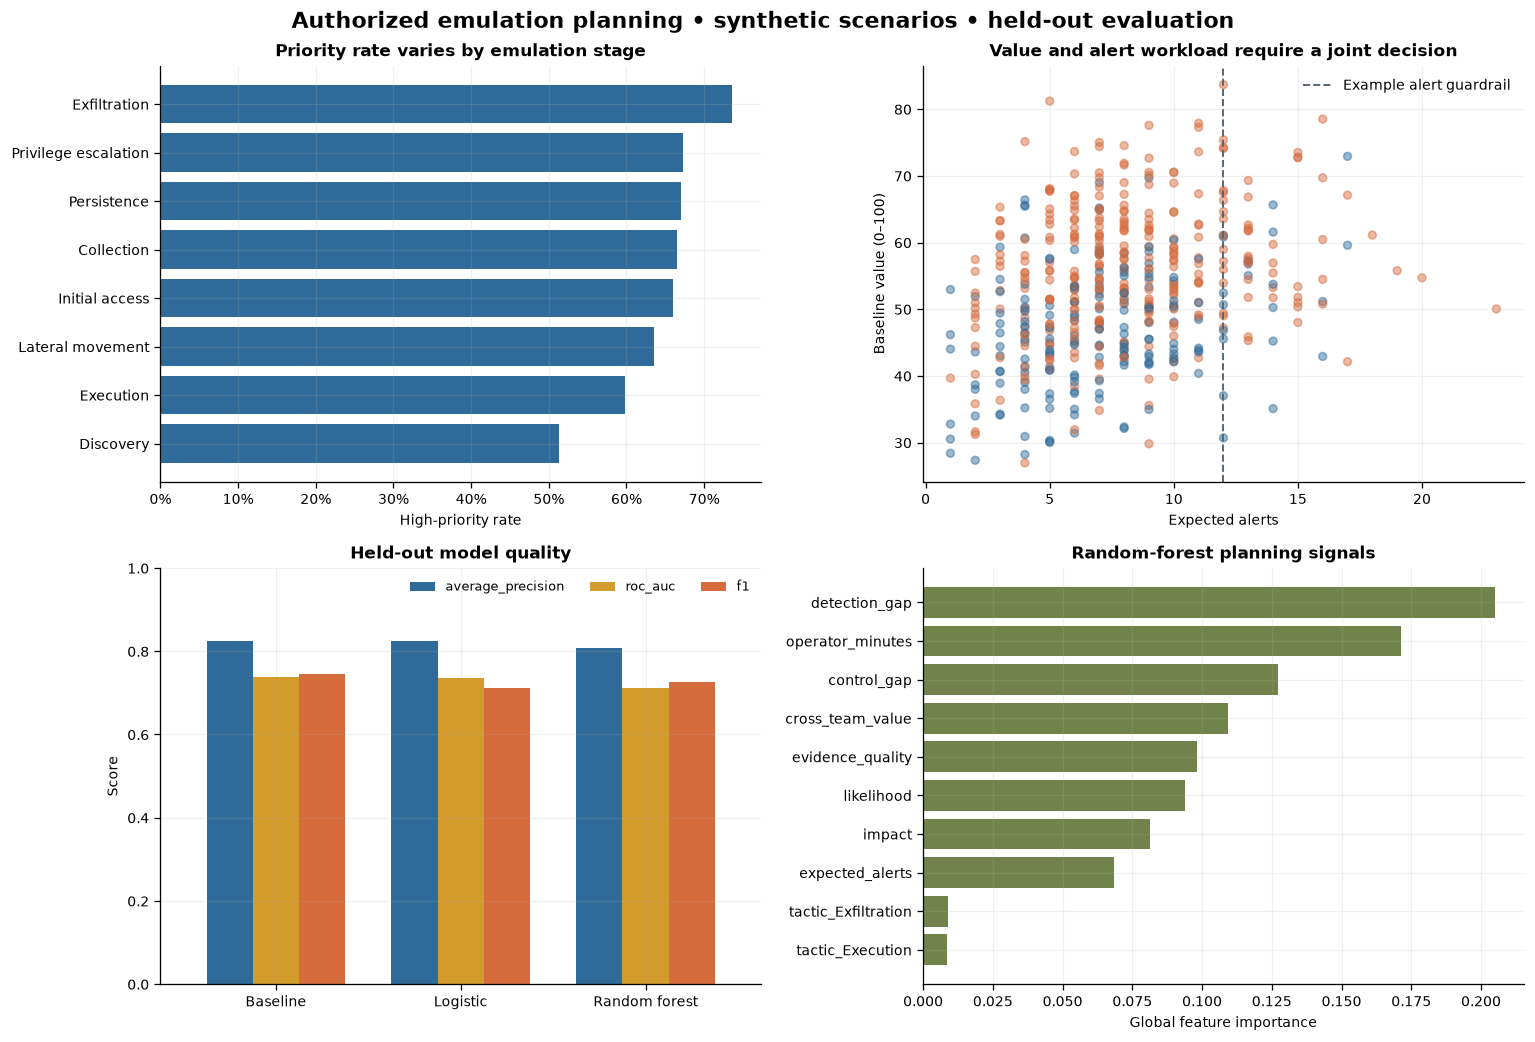

In [4]:
feature_columns = [
    "impact", "likelihood", "control_gap", "detection_gap", "evidence_quality",
    "expected_alerts", "operator_minutes", "cross_team_value", "tactic",
]
numeric_features = feature_columns[:-1]
categorical_features = ["tactic"]
train_index, test_index = train_test_split(
    np.arange(len(scenarios)), test_size=0.28, random_state=SEED,
    stratify=scenarios["high_priority"],
)
X_train = scenarios.loc[train_index, feature_columns]
X_test = scenarios.loc[test_index, feature_columns]
y_train = scenarios.loc[train_index, "high_priority"]
y_test = scenarios.loc[test_index, "high_priority"]

logistic = build_pipeline(
    numeric_features, categorical_features,
    LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
)
forest = build_pipeline(
    numeric_features, categorical_features,
    RandomForestClassifier(n_estimators=240, min_samples_leaf=6, class_weight="balanced", random_state=SEED),
)
logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)
model_probabilities = {
    "Baseline": scenarios.loc[test_index, "baseline_value"].to_numpy() / 100,
    "Logistic": logistic.predict_proba(X_test)[:, 1],
    "Random forest": forest.predict_proba(X_test)[:, 1],
}
metric_rows = []
for model_name, probabilities in model_probabilities.items():
    result = model_metrics(y_test, probabilities, 0.5)
    metric_rows.append({"model": model_name, **result})
metrics_table = pd.DataFrame(metric_rows).set_index("model")
importance = feature_importance_table(forest).head(10).sort_values("importance")

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.2))
tactic_rate = scenarios.groupby("tactic")["high_priority"].mean().sort_values()
axes[0, 0].barh(tactic_rate.index, tactic_rate.values, color=BLUE)
axes[0, 0].set(title="Priority rate varies by emulation stage", xlabel="High-priority rate")
axes[0, 0].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

sample = scenarios.sample(500, random_state=SEED)
axes[0, 1].scatter(sample["expected_alerts"], sample["baseline_value"],
                   c=np.where(sample["high_priority"].eq(1), ORANGE, BLUE), alpha=0.48, s=24)
axes[0, 1].axvline(12, color=SLATE, linestyle="--", linewidth=1.2, label="Example alert guardrail")
axes[0, 1].set(title="Value and alert workload require a joint decision", xlabel="Expected alerts", ylabel="Baseline value (0–100)")
axes[0, 1].legend(frameon=False)

metric_view = metrics_table[["average_precision", "roc_auc", "f1"]]
metric_view.plot(kind="bar", ax=axes[1, 0], color=[BLUE, GOLD, ORANGE], width=0.75)
axes[1, 0].set(title="Held-out model quality", xlabel="", ylabel="Score", ylim=(0, 1))
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(frameon=False, ncol=3, fontsize=8)

axes[1, 1].barh(importance["feature"].str.replace("numeric__", "").str.replace("categorical__", ""),
                importance["importance"], color=OLIVE)
axes[1, 1].set(title="Random-forest planning signals", xlabel="Global feature importance")
fig.suptitle("Authorized emulation planning • synthetic scenarios • held-out evaluation", fontsize=14, fontweight="bold")
fig.tight_layout()

print(metrics_table.round(3).to_string())
print("\nDecision insight: prioritize high-value scenarios below the alert guardrail, then validate the rest in smaller batches.")


## Checks

Executable assertions protect the dataset grain, metric bounds, holdout separation, and operational guardrails.


In [5]:
assert scenarios["scenario_id"].is_unique
assert scenarios.isna().sum().sum() == 0
assert set(scenarios["high_priority"].unique()) <= {0, 1}
assert set(train_index).isdisjoint(set(test_index))
assert metrics_table[["average_precision", "roc_auc", "precision", "recall", "f1"]].apply(lambda column: column.between(0, 1).all()).all()
assert backlog["expected_alerts"].max() <= alert_guardrail
print("All checks passed: unique scenarios, complete features, clean holdout, bounded metrics, and a workload-aware backlog.")


All checks passed: unique scenarios, complete features, clean holdout, bounded metrics, and a workload-aware backlog.


## Next Steps

- Replace synthetic inputs only with approved emulation-plan metadata and documented labels.
- Add rules-of-engagement constraints, asset-owner approvals, maintenance windows, and rollback readiness.
- Calibrate probability and workload estimates on completed exercises; never interpret synthetic scores as production performance.
- Publish a joint red/blue after-action record linking each scenario to expected telemetry, observed alerts, and remediation owners.
